# Tema : Modelo LSTM

![](src/img/logo_utb.png)
![](src/img/logo_etd.png)
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Ejercicio 1. Demanda de electricidad cada media hora

- Una aplicación común de estos modelos es la modelización de la demanda de electricidad. Tenemos una muestra la demanda de electricidad cada media hora (MWh) en Victoria, Australia, durante el período 2012-2014, junto con las temperaturas (en grados Celsius) para el mismo período en Melbourne (la ciudad más grande de Victoria).


In [1]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')


I0000 00:00:1779290093.463703  247382 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779290093.464242  247382 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779290093.516287  247382 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779290095.661314  247382 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# datos de electricidad
github_data = "https://raw.githubusercontent.com/fersalme/regresion-lineal-series-tiempo/refs/heads/main/data/vic_elec.csv"
vic_elec = pd.read_csv(github_data, parse_dates=["ds"])

vic_elec_df = (
    vic_elec
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index().rename_axis(None, axis="columns")
    .assign(ds=lambda x: pd.to_datetime(x["ds"]).dt.normalize())
    .groupby(["ds", "Holiday"])
    .agg({
        "Demand": "sum",
        "Temperature": "max"
    })
    .reset_index()
    .assign(
        Demand=lambda x: x["Demand"] / 1e3,
        weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Working_Day=lambda x: ~x["Holiday"] & ~x["weekend"],
        Cooling=lambda x: x["Temperature"].clip(lower=18)
    )
    .drop(columns=["weekend", "Holiday"])
)

vic_elec_df.head()


,ds,Demand,Temperature,Working_Day,Cooling
0,2012-01-01,222.437912,32.7,False,32.7
1,2012-01-02,257.964724,39.6,False,39.6
2,2012-01-03,267.098605,31.8,True,31.8
3,2012-01-04,222.742287,25.1,True,25.1
4,2012-01-05,210.585240,21.2,True,21.2


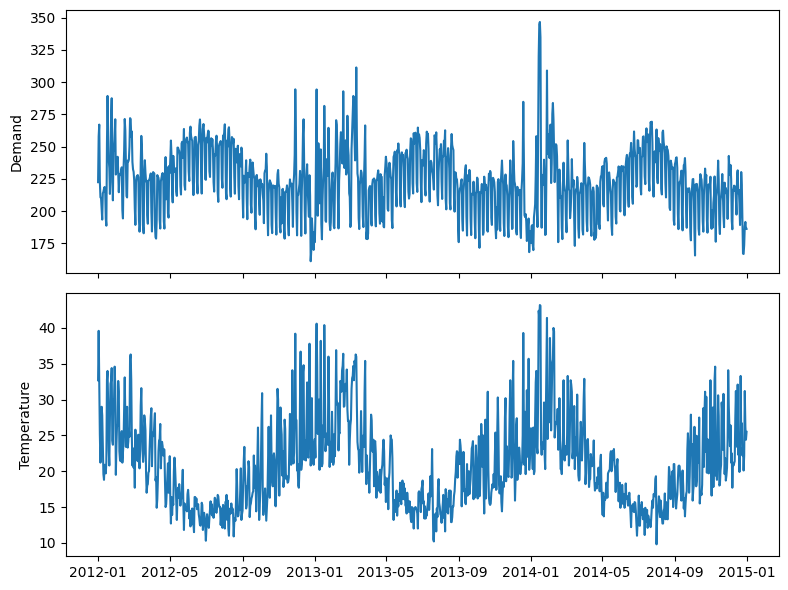

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(vic_elec_df["ds"], vic_elec_df["Demand"])
axes[0].set_ylabel("Demand")
axes[1].plot(vic_elec_df["ds"], vic_elec_df["Temperature"])
axes[1].set_ylabel("Temperature")
plt.tight_layout()
plt.show()

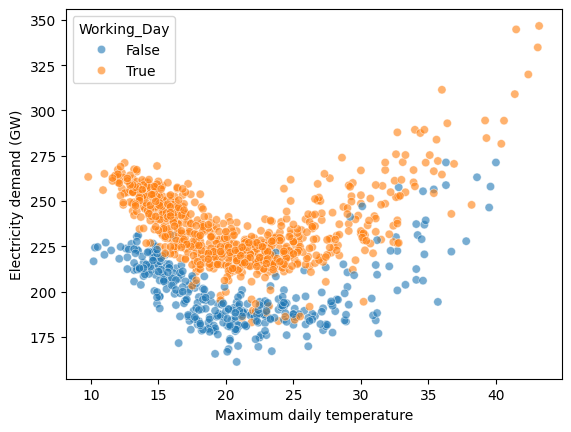

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_df, x="Temperature", y="Demand",
    hue="Working_Day", palette="tab10", alpha=0.6, ax=ax)
ax.set(
    xlabel="Maximum daily temperature",
    ylabel="Electricity demand (GW)",
)
plt.show()

Si se representa la demanda de electricidad en función de la temperatura, se observa que existe una relación no lineal entre ambas, con un aumento de la demanda para temperaturas bajas (debido a la calefacción) y un aumento para temperaturas altas (debido a la refrigeración).

## Modelo usando LSTM
Usando el mismo dataset de temperatura procedemos a pronosticar por LSTM

### Pasos :
1. Escalar los datos entre 0-1
2. Convertir la serie de tiempo en secuencias. Transformamos los datos de series temporales en ventanas deslizantes para la entrada de LSTM.
3. Dividido en conjuntos de prueba y entrenamiento
4. Construí el modelo LSTM

In [5]:
df = vic_elec_df.copy()
df.set_index('ds', inplace=True)
df.head()

,Demand,Temperature,Working_Day,Cooling
ds,,,,
2012-01-01,222.437912,32.7,False,32.7
2012-01-02,257.964724,39.6,False,39.6
2012-01-03,267.098605,31.8,True,31.8
2012-01-04,222.742287,25.1,True,25.1
2012-01-05,210.585240,21.2,True,21.2


$$\hat{x}_i = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}$$

Donde:

| Símbolo | Descripción |
|---------|-------------|
| $x_i$ | Valor original |
| $\hat{x}_i$ | Valor normalizado $\in [0, 1]$ |
| $x_{\min}$ | Mínimo de la serie |
| $x_{\max}$ | Máximo de la serie |

Para un rango personalizado $[a, b]$:

$$\hat{x}_i = a + \frac{(x_i - x_{\min})(b - a)}{x_{\max} - x_{\min}}$$

Y la **transformación inversa** para recuperar la escala original:

$$x_i = \hat{x}_i \cdot (x_{\max} - x_{\min}) + x_{\min}$$

In [6]:
# Escalar los valores de la serie
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print(f"Dimension matriz {scaled_data.ndim}")
print("\nEncabezado matriz")
for i in range(16):
    print(f"Fila {i} : {scaled_data[i]}")

Dimension matriz 2

Encabezado matriz
Fila 0 : [0.33042727 0.68562874 0.         0.58333333]
Fila 1 : [0.5218241  0.89221557 0.         0.85714286]
Fila 2 : [0.57103189 0.65868263 1.         0.54761905]
Fila 3 : [0.33206706 0.45808383 1.         0.28174603]
Fila 4 : [0.2665723  0.34131737 1.         0.12698413]
Fila 5 : [0.26474759 0.41317365 1.         0.22222222]
Fila 6 : [0.22315565 0.5748503  0.         0.43650794]
Fila 7 : [0.17405621 0.53892216 0.         0.38888889]
Fila 8 : [0.28391287 0.4251497  1.         0.23809524]
Fila 9 : [0.29046631 0.29341317 1.         0.06349206]
Fila 10 : [0.30296309 0.26946108 1.         0.03174603]
Fila 11 : [0.31032766 0.33233533 1.         0.11507937]
Fila 12 : [0.29558353 0.31137725 1.         0.08730159]
Fila 13 : [0.17896586 0.29640719 0.         0.06746032]
Fila 14 : [0.14861989 0.34730539 0.         0.13492063]
Fila 15 : [0.49205761 0.68862275 1.         0.58730159]


## La serie de tiempo es
| $t_1$ | $t_2$ | $t_3$ | $t_4$ | $t_5$ | $t_6$ | $t_7$ | $t_8$ | $t_9$ | $t_{10}$ |
|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:------:|
| $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |

## Con tamaño de ventana 4 y horizonte 1 tenemos una secuencia que se desliza un paso a la vez

| Ventana (X) | | | | Objetivo (y) |
|:-----------:|:-----------:|:-----------:|:-----------:|:------------:|
| $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ |
| $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ |
| $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ |
| $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ |
| $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ |
| $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |
| **paso 1** | **paso 2** | **paso 3** | **paso 4** | **horizonte** |

## Generando estas muestras para la red neuronal

| | **Muestra 1** | **Muestra 2** | **Muestra 3** | **Muestra 4** | **Muestra 5** | **Muestra 6** |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| paso 1 | $y_1$ | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ |
| paso 2 | $y_2$ | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ |
| paso 3 | $y_3$ | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ |
| paso 4 | $y_4$ | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ |
| **objetivo** | $y_5$ | $y_6$ | $y_7$ | $y_8$ | $y_9$ | $y_{10}$ |

Con `window_size = 4`, `horizon = 1` y serie de $T = 10$, el número de muestras es:

$$n\_samples = T - window\_size - horizon + 1 = 10 - 4 - 1 + 1 = 6$$

Con `window_size = 4` y `horizon = 1`, shape resultante:

| Tensor | Dimensiones | Valores |
|--------|------------|---------|
| `X` | `(n_samples, window_size, n_features)` | `(6, 4, 1)` |
| `y` | `(n_samples, horizon)` | `(6, 1)` |

Un tensor es una generalización matemática de escalares, vectores y matrices a cualquier número de dimensiones.

| | **Escalar** | **Vector** | **Matriz** | **Tensor 3D** |
|---|:---:|:---:|:---:|:---:|
| **Ejes** | 0 | 1 | 2 | 3 |
| **Shape** | `()` | `(3,)` | `(3, 3)` | `(n, m, p)` |
| **Índice** | — | $x_i$ | $x_{ij}$ | $x_{ijk}$ |
| **Ejemplo** | $5$ | $[1, 2, 3]$ | $\begin{bmatrix}1&2&3\\4&5&6\\7&8&9\end{bmatrix}$ | $\mathbf{X}[i,j,k]$ |
| **En NumPy** | `np.array(5)` | `np.array([1,2,3])` | `np.zeros((3,3))` | `np.zeros((n,m,p))` |
| **En LSTM** | Un valor $y_t$ | Una ventana $[y_1 \dots y_w]$ | Ventanas de una variable | Ventanas de múltiples variables |

In [7]:
# Crear secuencia de datos de la serie
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        # En NumPy usar siempre slicing estándar [start:stop:step]
        X.append(data[i:i + window])
        y.append(data[i + window, 0]) # indice 0 es la variable a modelar
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 15)

print("Secuencia de la ventana en la primera muestra X\n")
print(X[0])
print("\nSecuencia de la ventana en la primera muestra y posicion 15 en la serie")
print(y[0])

Secuencia de la ventana en la primera muestra X

[[0.33042727 0.68562874 0.         0.58333333]
 [0.5218241  0.89221557 0.         0.85714286]
 [0.57103189 0.65868263 1.         0.54761905]
 [0.33206706 0.45808383 1.         0.28174603]
 [0.2665723  0.34131737 1.         0.12698413]
 [0.26474759 0.41317365 1.         0.22222222]
 [0.22315565 0.5748503  0.         0.43650794]
 [0.17405621 0.53892216 0.         0.38888889]
 [0.28391287 0.4251497  1.         0.23809524]
 [0.29046631 0.29341317 1.         0.06349206]
 [0.30296309 0.26946108 1.         0.03174603]
 [0.31032766 0.33233533 1.         0.11507937]
 [0.29558353 0.31137725 1.         0.08730159]
 [0.17896586 0.29640719 0.         0.06746032]
 [0.14861989 0.34730539 0.         0.13492063]]

Secuencia de la ventana en la primera muestra y posicion 15 en la serie
0.49205760617125727


In [8]:
# Dividir en set de prueba y entrenamiento
split = int(0.85 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
# Construir el modelo LSTM
# Definiremos la estructura de la red neuronal. Aquí:
#  1. LSTM aprende patrones temporales
#  2. El dropout reduce el sobreajuste
#  3. La capa densa genera la demanda de energia del día siguiente
#  4. El error cuadrático medio se utiliza como función de pérdida

model = keras.Sequential()
model.add(
    keras.layers.LSTM(
        100, # El argumento define el número de unidades (neuronas) de la capa LSTM
        input_shape=(
            X_train.shape[1],  # Pasos de tiempo por ventana
            X_train.shape[2]   # Variables en cada paso
            )
        )
    )

# Durante el entrenamiento, el Dropout apaga aleatoriamente el 20% de las neuronas de la capa anterior
# en cada secuecienca para evitar el overfitting
model.add(keras.layers.Dropout(0.2))

# Capa de salida completamente conectada que colapsa los estados ocultos a un solo valor y^​t ​= Wy​ x ht​ + by​
model.add(keras.layers.Dense(1))

# Define la función de pérdida, el optimizador y las métricas de evaluación del entrenamiento
model.compile(loss="mse", optimizer="adam", metrics=["mae"])
model.summary()


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 42,101 (164.46 KB)
 Trainable params: 42,101 (164.46 KB)
 Non-trainable params: 0 (0.00 B)


E0000 00:00:1779290097.974123  247382 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
# Entrenar el modelo
# El modelo aprende los patrones demanda de energia a partir de datos históricos y se entrena durante 30 épocas.
history = model.fit(
    X_train, y_train,
    epochs     = 30, # Una época es una pasada completa del modelo por todo el conjunto de entrenamiento.
    batch_size = 16, # Define el número de muestras que el modelo procesa antes de actualizar los pesos.
    shuffle    = False   # Preservar orden temporal
)


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0417 - mae: 0.1651
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0225 - mae: 0.1206
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0196 - mae: 0.1120
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0184 - mae: 0.1069
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0174 - mae: 0.1045
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0159 - mae: 0.0986
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0143 - mae: 0.0930
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mae: 0.0878
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0127 - mae: 0.0868
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0115 - mae: 0.0839
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 - mae: 0.0799
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0107 - mae: 0.0792
Epoch 13/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

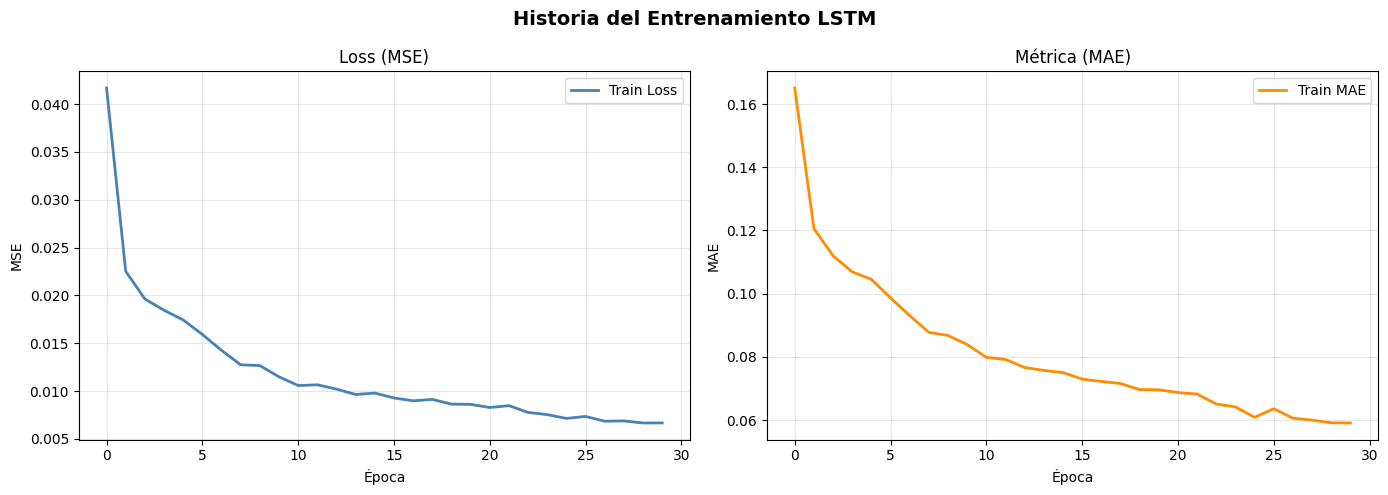

In [11]:
# Graficar historia del entrenamiento
# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2, color="steelblue")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Métrica (MAE)
axes[1].plot(history.history["mae"], label="Train MAE", linewidth=2, color="darkorange")
axes[1].set_title("Métrica (MAE)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Historia del Entrenamiento LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor              = "val_loss",  # Métrica a observar
    patience             = 10,          # Épocas sin mejora antes de detener
    restore_best_weights = True         # Restaurar pesos del mejor epoch
)

# Entrenamiento con early stopping
history = model.fit(
    X_train, y_train,
    epochs          = 100,
    batch_size      = 32,
    validation_split = 0.1, # Validación (10%) en cada epoca de la red
    callbacks       = [early_stop],
    shuffle         = False,
    verbose         = 1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0070 - mae: 0.0600 - val_loss: 0.0023 - val_mae: 0.0364
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - mae: 0.0576 - val_loss: 0.0023 - val_mae: 0.0357
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - mae: 0.0583 - val_loss: 0.0022 - val_mae: 0.0351
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - mae: 0.0560 - val_loss: 0.0021 - val_mae: 0.0342
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - mae: 0.0571 - val_loss: 0.0022 - val_mae: 0.0350
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - mae: 0.0580 - val_loss: 0.0021 - val_mae: 0.0348
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - mae: 0.0560 - val_loss: 0.0021 - val_mae: 0.0347
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064 - mae: 0.0563 - val_loss: 0.0021 - val_mae: 0.0344
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - los

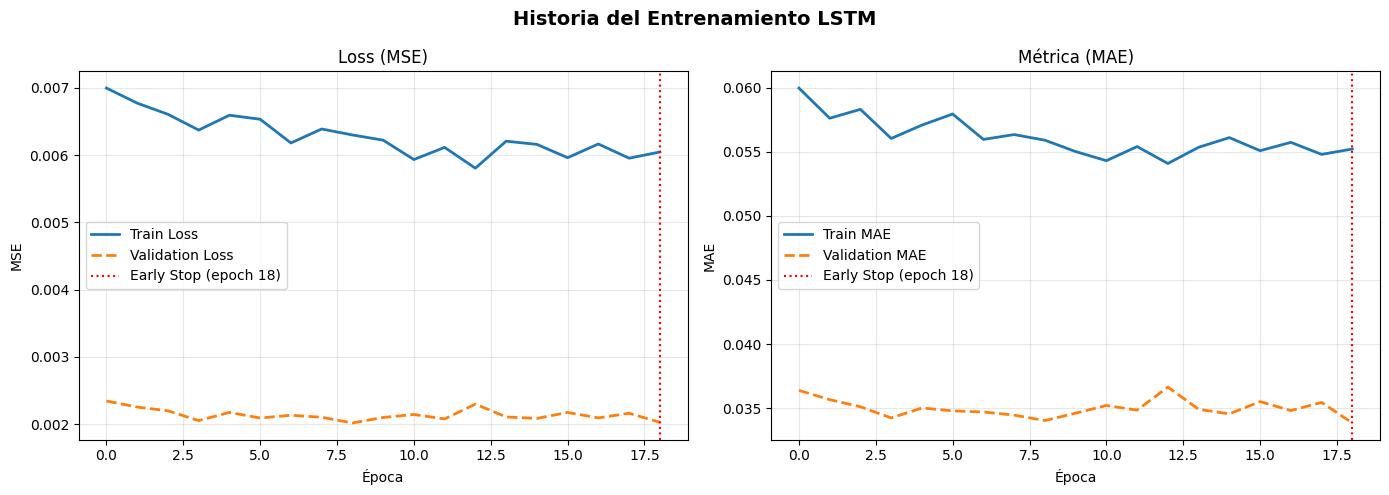

In [13]:
# Gráfico de historia del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history["loss"],     label="Train Loss",      linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2, linestyle="--")
axes[0].axvline(
    x     = early_stop.stopped_epoch,
    color = "red",
    linestyle = ":",
    label = f"Early Stop (epoch {early_stop.stopped_epoch})"
)
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Métrica (MAE)
axes[1].plot(history.history["mae"],     label="Train MAE",      linewidth=2)
axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2, linestyle="--")
axes[1].axvline(
    x         = early_stop.stopped_epoch,
    color     = "red",
    linestyle = ":",
    label     = f"Early Stop (epoch {early_stop.stopped_epoch})"
)
axes[1].set_title("Métrica (MAE)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Historia del Entrenamiento LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
# Predicción en escala normalizada
y_pred_scaled = model.predict(X_test)

# Los valores escalados se convierten de nuevo a valores de demanda reales.
pred_inv = scaler.inverse_transform(
    np.c_[y_pred_scaled, np.zeros((len(y_pred_scaled), df.shape[1] - 1))]
)[:, 0]

# Lo mismo con la serie original test
y_test_inv = scaler.inverse_transform(
    np.c_[y_test, np.zeros((len(y_test), df.shape[1] - 1))]
)[:, 0]



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


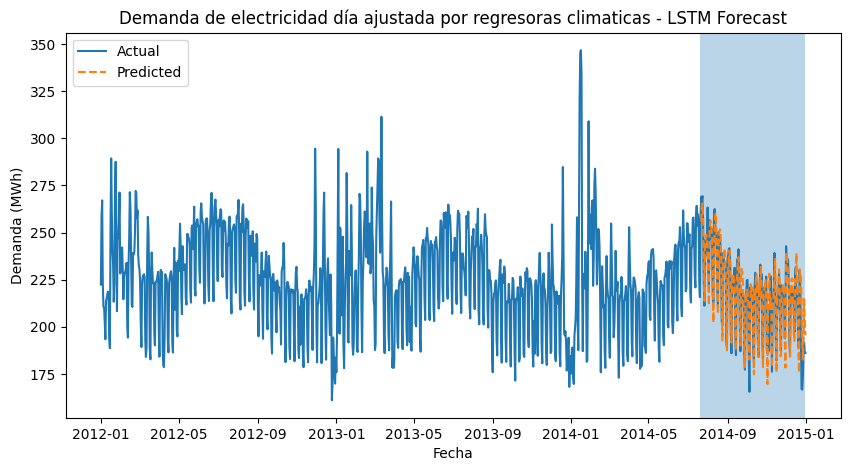

In [15]:
# Representación gráfica de los valores reales frente a los valores previstos.
time = df.index
predict_time = time[-len(y_test):]

plt.figure(figsize=(10, 5))
plt.plot(time, df.Demand, label="Actual")
plt.plot(predict_time, pred_inv, linestyle="--", label="Predicted")

highlight = int(len(time) * 0.85)
plt.axvspan(time[highlight], time[-1], alpha=0.3)

plt.title("Demanda de electricidad día ajustada por regresoras climaticas - LSTM Forecast")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")
plt.legend()
plt.show()

In [16]:
# Evaluar el rendimiento del modelo
# Evaluamos el rendimiento del modelo:
# MSE: error cuadrático medio
# MAE: error promedio
# R²: precisión de las predicciones con respecto a los valores reales

mse = mean_squared_error(y_test_inv, pred_inv)
mae = mean_absolute_error(y_test_inv, pred_inv)
r2 = r2_score(y_test_inv, pred_inv)

metricas = pd.DataFrame({
    "Métrica":      ["MSE", "RMSE", "MAE", "R²"],
    "Valor":        [mse, np.sqrt(mse), mae, r2],
    "Descripción":  [
        "Error cuadrático medio",
        "Raíz del error cuadrático medio",
        "Error absoluto medio",
        "Precisión respecto a valores reales"
    ]
})

print(metricas.to_string(index=False))

Métrica      Valor                         Descripción
    MSE 112.892329              Error cuadrático medio
   RMSE  10.625080     Raíz del error cuadrático medio
    MAE   7.726480                Error absoluto medio
     R²   0.773065 Precisión respecto a valores reales
